# Multi-Species Classification with the Crop Model

This notebook is a work in process showing how to train and use a [DeepForest `CropModel`](https://deepforest.readthedocs.io/en/v2.1.0/user_guide/03_cropmodels.html) [1] for multi-species tree classification in the following steps:

1. **Train a crop classifier** on the species annotations from the TreeAI dataset [2]
2. **Run multi-species inference** combining the fine-tuned crown model with the crop classifier

The following key parts are not covered yet but will be (hopefully) shortly:

1. **Data augmentations** in crop model training (AFAIK, not directly supported by DeepForest yet)
2. **Multi-species annotations vs predictions plotting** with common species color mapping
3. **Multi-species evaluation**

This notebook assumes you have already run [`treeai-example.ipynb`](treeai-example.ipynb) to upload the images and produce the fine-tuned crown checkpoint (`crown-fine-tune.pl` in the models volume).

## 0. Setup

Let us start with some imports:

In [ ]:
import os
import time
from os import path

import matplotlib.pyplot as plt
import pandas as pd
from pytorch_lightning import callbacks, loggers

import deepforest_modal_app as dma
import treeai_utils
from deepforest_modal_app import plot_utils

We define the analysis parameters. `fine_tuned_filepath` points to the crown model checkpoint produced by `treeai-example.ipynb`. `max_species_per_image` controls how much label diversity is allowed per image when building the crop-model training and validation sets:

In [ ]:
# path to the Tree AI dataset
base_dir = "treeai-data/12_RGB_ObjDet_640_fL"
# to name folders in the modal volumes
dataset_id = "12_RGB_ObjDet_640_fL"

# fine-tuned crown model checkpoint (produced by treeai-example.ipynb)
fine_tuned_filepath = path.join(dataset_id, "crown-fine-tune.pl")
# output crop model checkpoint
crop_filepath = path.join(dataset_id, "crop-picea-pinus-fagus.pl")

# target species
target_species = ["picea abies", "pinus sylvestris", "fagus sylvatica"]

# dataset filtering args
max_species_per_image = 4

# viz args
figwidth = plt.rcParams["figure.figsize"][0]
figheight = plt.rcParams["figure.figsize"][1]

# for reproducibility
random_state = 0

# for Comet ML
comet_ml_api_key = os.getenv("COMET_ML_API_KEY", "")
comet_ml_project_name = "deepforest-modal-app"
comet_ml_workspace = "martibosch"

### Loading and uploading the dataset

We filter the TreeAI annotations to images containing at least one occurrence of the target species and then keep only images containing at most `max_species_per_image` distinct species:

In [ ]:
# load TreeAI dataset
train_gdf, train_img_dir, species_label_dict = treeai_utils.get_annot_gdf(
    base_dir, which="train", species=target_species
)
val_gdf, val_img_dir, _ = treeai_utils.get_annot_gdf(
    base_dir, which="val", species=target_species
)

# ensure that annotations are strictly larger than 1 px
train_gdf = treeai_utils.ensure_gt_1px(train_gdf)
val_gdf = treeai_utils.ensure_gt_1px(val_gdf)

# keep only images with limited species diversity
train_img_species_count = train_gdf.groupby("image_path")["label"].nunique()
val_img_species_count = val_gdf.groupby("image_path")["label"].nunique()
train_img_filenames = train_img_species_count[
    train_img_species_count.le(max_species_per_image)
].index
val_img_filenames = val_img_species_count[
    val_img_species_count.le(max_species_per_image)
].index
train_gdf = train_gdf[train_gdf["image_path"].isin(train_img_filenames)]
val_gdf = val_gdf[val_gdf["image_path"].isin(val_img_filenames)]
########################################################################################
print(
    f"Using {len(train_img_filenames)} train images ({len(train_gdf)} annotations) and "
    f"{len(val_img_filenames)} validation images ({len(val_gdf)}) with at most "
    f"{max_species_per_image} species per image."
)

remote_img_dir = dataset_id
val_img_filenames = val_gdf["image_path"].unique()
val_gdf.head()

100%|███████████████████████████████████████████████████████| 303/303 [00:03<00:00, 81.80it/s]


Using 25 train images (743 annotations) and 4 validation images (132) with at most 4 species per image.


,label,image_path,xmin,ymin,xmax,ymax,geometry
5471,19,000000003109.png,6.00000,461.99968,38.99968,503.99968,"POLYGON ((39 462, 39 504, 6 504, 6 462, 39 462))"
5472,19,000000003109.png,126.99968,84.00000,250.00000,196.00000,"POLYGON ((250 84, 250 196, 127 196, 127 84, 25..."
5473,19,000000003109.png,185.00000,151.00000,311.00000,281.00000,"POLYGON ((311 151, 311 281, 185 281, 185 151, ..."
5474,12,000000003109.png,232.99968,455.99968,316.00000,565.00000,"POLYGON ((316 456, 316 565, 233 565, 233 456, ..."
5475,4,000000003109.png,307.00032,464.00032,360.00000,566.00032,"POLYGON ((360 464, 360 566, 307 566, 307 464, ..."


In [ ]:
# upload (if needed) train and validation images
for img_dir in [train_img_dir, val_img_dir]:
    dma.ensure_imgs(
        img_dir,
        remote_img_dir=remote_img_dir,
    )

## 1. Training the crop model

The `train_crop_model` function extracts crops from each bounding box annotation and trains an image classifier (a ResNet by default) on them.

Here we rely on the default crop-model and trainer settings from `deepforest_modal_app.settings`, add an `EarlyStopping` callback, and log training metrics to Comet so we can inspect the validation curves right after training.

In [ ]:
comet_logger = loggers.CometLogger(
    api_key=comet_ml_api_key,
    project=comet_ml_project_name,
    workspace=comet_ml_workspace,
)

early_stopping_patience = 10
early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=early_stopping_patience,
)

with dma.app.run():
    _start = time.perf_counter()
    dma.train_crop_model.remote(
        train_gdf,
        remote_img_dir,
        test_df=val_gdf,
        dst_filepath=crop_filepath,
        logger=comet_logger,
        callbacks=[early_stopping],
    )
    print(f"Crop model training completed in {time.perf_counter() - _start:.1f}s")
    comet_logger.experiment.end()

Crop model training completed in 157.1s


## 2. Multi-species inference

We now run inference using both the fine-tuned crown model and the crop classifier. Each predicted bounding box gets a species label from the crop model (stored in the `cropmodel_label` column):

In [ ]:
with dma.app.run():
    _start = time.perf_counter()
    ms_pred_gdf = dma.predict.remote(
        img_filenames=val_img_filenames,
        remote_img_dir=remote_img_dir,
        checkpoint_filepath=fine_tuned_filepath,
        crop_model_filepath=crop_filepath,
    )
    print(
        f"Fine-tuned + crop-model inference predicted {len(val_img_filenames)} tiles "
        f"in {time.perf_counter() - _start:.1f}s"
    )

Fine-tuned + crop-model inference predicted 4 tiles in 24.6s


The resulting data frame has two additional columns, i.e., the crop model label and score:

In [ ]:
ms_pred_gdf.head()

,xmin,ymin,xmax,ymax,label,score,image_path,cropmodel_label,cropmodel_score,geometry
0,0.0,101.0,117.0,260.0,Tree,0.407013,000000003109.png,19,0.981012,"POLYGON ((117 101, 117 260, 0 260, 0 101, 117 ..."
1,163.0,109.0,334.0,282.0,Tree,0.394902,000000003109.png,19,0.999998,"POLYGON ((334 109, 334 282, 163 282, 163 109, ..."
2,1.0,259.0,135.0,446.0,Tree,0.377056,000000003109.png,4,0.924732,"POLYGON ((135 259, 135 446, 1 446, 1 259, 135 ..."
3,3.0,0.0,87.0,45.0,Tree,0.370847,000000003109.png,19,0.565517,"POLYGON ((87 0, 87 45, 3 45, 3 0, 87 0))"
4,381.0,192.0,501.0,307.0,Tree,0.325381,000000003109.png,4,0.998965,"POLYGON ((501 192, 501 307, 381 307, 381 192, ..."


## 3. Evaluation

As mentioned above, this notebook is a work-in-progress so we will evaluate by visual inspection only:

/home/martibosch/libraries/deepforest-modal-app/.pixi/envs/user-guide/lib/python3.12/site-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/home/martibosch/libraries/deepforest-modal-app/.pixi/envs/user-guide/lib/python3.12/site-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


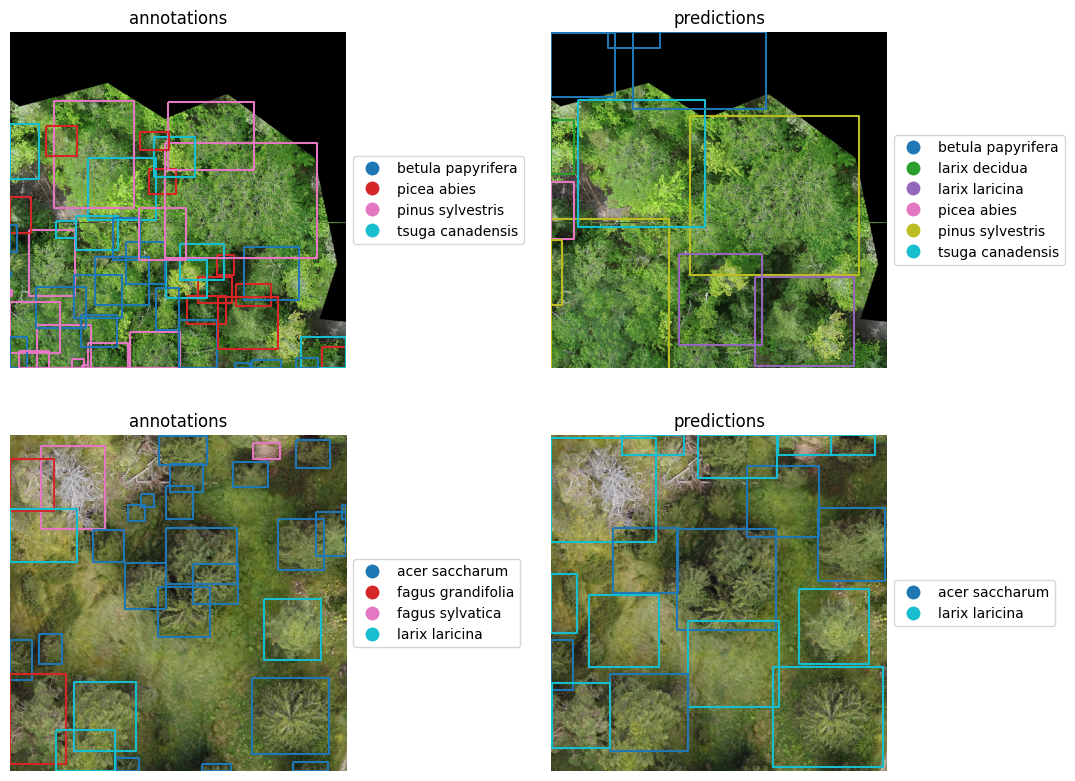

In [ ]:
n_plot_imgs = 2
plot_img_filenames = pd.Series(val_img_filenames).sample(
    n_plot_imgs, random_state=random_state
)

fig = plot_utils.plot_annot_vs_pred(
    ms_pred_gdf[ms_pred_gdf["image_path"].isin(plot_img_filenames)],
    val_gdf[val_gdf["image_path"].isin(plot_img_filenames)],
    val_img_dir,
    label_dict=species_label_dict,
)

As we can see, there is notable room for improvement, so you can expect this notebook to be updated shortly

## References

1. Weinstein, B. G., Marconi, S., Aubry‐Kientz, M., Vincent, G., Senyondo, H., & White, E. P. (2020). DeepForest: A Python package for RGB deep learning tree crown delineation. Methods in Ecology and Evolution, 11(12), 1743-1751.
2. Beloiu Schwenke, M., Xia, Z., Novoselova, I., Gessler, A., Kattenborn, T., Mosig, C., Puliti, S., Waser, L., Rehush, N., Cheng, Y., Xinliang, L., Griess, V. C., & Mokroš, M. (2025). TreeAI Global Initiative - Advancing tree species identification from aerial images with deep learning (TreeAI.V1.2) [Data set]. Zenodo. https://doi.org/10.5281/zenodo.15351054